## E2 - architecture ablation

Toggles the depthwise-separable conv (block2) and the dilated conv (block3) on/off against a standard 3x3 conv, Adam held fixed since E1 already settled that. `full_citrusnet` (both toggles True) is the existing baseline, not retrained.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt

from citrus_model import CitrusNetArchAblation, init_weights
from citrus_common import load_normalization_stats, get_transforms, CitrusLeafDataset
from citrus_train import set_seed, fit

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Data

In [2]:
set_seed(42)

mean, std = load_normalization_stats()

train_transform = get_transforms(augment=True, mean=mean, std=std, size=224)
val_transform = get_transforms(augment=False, mean=mean, std=std, size=224)

train_dataset = CitrusLeafDataset(root_dir="processed/224", split="train", transform=train_transform)
val_dataset = CitrusLeafDataset(root_dir="processed/224", split="val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

len(train_dataset), len(val_dataset)

(1131, 242)

### Loss and variant configs

Adam (lr=1e-3, weight_decay=1e-4) for every run - E1 already picked Adam, so it's fixed here while the architecture varies. `full_citrusnet` isn't trained, its history comes from history_baseline.csv.

In [3]:
class_weights = torch.tensor([0.9921, 0.9240, 1.1880, 0.9363], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

variant_configs = {
    "standard_only": dict(use_depthwise_separable=False, use_dilated=False),
    "plus_ds": dict(use_depthwise_separable=True, use_dilated=False),
    "plus_dilated": dict(use_depthwise_separable=False, use_dilated=True),
}

### Training runs

Fresh model + init per variant, seed reset right before each build. fit()'s history dict doesn't come back with an explicit epoch column (learned that the hard way in the E1 notebook), so one gets inserted before saving to CSV.

In [4]:
os.makedirs("checkpoints", exist_ok=True)

histories_ordered = {}
param_counts = {}

for name, flags in variant_configs.items():
    set_seed(42)
    model = CitrusNetArchAblation(num_classes=4, **flags)
    init_weights(model)
    model = model.to(device)

    n_params = sum(p.numel() for p in model.parameters())
    param_counts[name] = n_params
    print(f"--- training: {name} (params={n_params}) ---")

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        max_epochs=100,
        early_stop_patience=10,
        scheduler=scheduler,
        checkpoint_path=f"checkpoints/arch_{name}_best.pt",
        verbose=True,
    )

    hist_df = pd.DataFrame(history)
    if "epoch" not in hist_df.columns:
        hist_df.insert(0, "epoch", range(1, len(hist_df) + 1))

    hist_df.to_csv(f"history_arch_{name}.csv", index=False)
    histories_ordered[name] = hist_df

--- training: standard_only (params=432100) ---
epoch   1  train_loss 0.9007  train_acc 0.6472  val_loss 1.2910  val_acc 0.5331  lr 1.00e-03
epoch   2  train_loss 0.4574  train_acc 0.8320  val_loss 0.6903  val_acc 0.7645  lr 1.00e-03
epoch   3  train_loss 0.3577  train_acc 0.8806  val_loss 0.4544  val_acc 0.8347  lr 1.00e-03
epoch   4  train_loss 0.2879  train_acc 0.9036  val_loss 0.1631  val_acc 0.9504  lr 1.00e-03
epoch   5  train_loss 0.2372  train_acc 0.9222  val_loss 0.0834  val_acc 0.9835  lr 1.00e-03
epoch   6  train_loss 0.2077  train_acc 0.9372  val_loss 0.0331  val_acc 1.0000  lr 1.00e-03
epoch   7  train_loss 0.2207  train_acc 0.9293  val_loss 0.2542  val_acc 0.8926  lr 1.00e-03
epoch   8  train_loss 0.2036  train_acc 0.9346  val_loss 0.0866  val_acc 0.9752  lr 1.00e-03
epoch   9  train_loss 0.1527  train_acc 0.9540  val_loss 0.0836  val_acc 0.9793  lr 1.00e-03
epoch  10  train_loss 0.1750  train_acc 0.9496  val_loss 0.7508  val_acc 0.7562  lr 5.00e-04
epoch  11  train_loss 

### Bring in the full CitrusNet baseline

416,036 params, best_epoch=30, best val_loss=0.00103, best val_acc=1.0000 - not retrained here.

In [5]:
full_df = pd.read_csv("history_baseline.csv")
if "epoch" not in full_df.columns:
    full_df.insert(0, "epoch", range(1, len(full_df) + 1))

all_histories = dict(histories_ordered)
all_histories["full_citrusnet"] = full_df

### Summary table

`epochs_to_reach_99pct` is the first epoch where val_acc >= 0.99, or "never". Rows kept in a fixed order rather than sorted, since the point here is the architecture toggles, not a speed ranking.

In [6]:
def summarize(name, df, use_ds, use_dil, n_params):
    best_idx = df["val_loss"].idxmin()
    reached = df[df["val_acc"] >= 0.99]
    epochs_to_99 = int(reached["epoch"].iloc[0]) if len(reached) > 0 else "never"

    return {
        "variant": name,
        "use_depthwise_separable": use_ds,
        "use_dilated": use_dil,
        "param_count": n_params,
        "epochs_run": int(df["epoch"].max()),
        "best_epoch": int(df.loc[best_idx, "epoch"]),
        "best_val_loss": float(df.loc[best_idx, "val_loss"]),
        "best_val_acc": float(df.loc[best_idx, "val_acc"]),
        "epochs_to_reach_99pct": epochs_to_99,
    }

rows = [
    summarize("standard_only", histories_ordered["standard_only"], False, False, param_counts["standard_only"]),
    summarize("plus_ds", histories_ordered["plus_ds"], True, False, param_counts["plus_ds"]),
    summarize("plus_dilated", histories_ordered["plus_dilated"], False, True, param_counts["plus_dilated"]),
    summarize("full_citrusnet", full_df, True, True, 416036),
]

summary_df = pd.DataFrame(rows)
summary_df

,variant,use_depthwise_separable,use_dilated,param_count,epochs_run,best_epoch,best_val_loss,best_val_acc,epochs_to_reach_99pct
0,standard_only,False,False,432100,52,42,0.001062,1.0,6
1,plus_ds,True,False,416036,42,32,0.001488,1.0,8
2,plus_dilated,False,True,432100,48,38,0.000638,1.0,7
3,full_citrusnet,True,True,416036,40,30,0.001026,1.0,4


### Parameter-count check

Dilation changes the receptive field, not the kernel size, so plus_dilated should match standard_only exactly. A depthwise-separable conv reaching 64 channels uses far fewer weights than a standard conv would, so plus_ds should come in well below standard_only.

In [7]:
standard_params = param_counts["standard_only"]
ds_params = param_counts["plus_ds"]
dilated_params = param_counts["plus_dilated"]

dilated_matches_standard = dilated_params == standard_params
ds_is_fewer = ds_params < standard_params

print(f"standard_only params: {standard_params}")
print(f"plus_ds params:       {ds_params}")
print(f"plus_dilated params:  {dilated_params}")
print(f"plus_dilated == standard_only (dilation doesn't add weights): {dilated_matches_standard}")
print(f"plus_ds < standard_only (depthwise-separable uses fewer weights): {ds_is_fewer}")

standard_only params: 432100
plus_ds params:       416036
plus_dilated params:  432100
plus_dilated == standard_only (dilation doesn't add weights): True
plus_ds < standard_only (depthwise-separable uses fewer weights): True


### Val loss, log scale

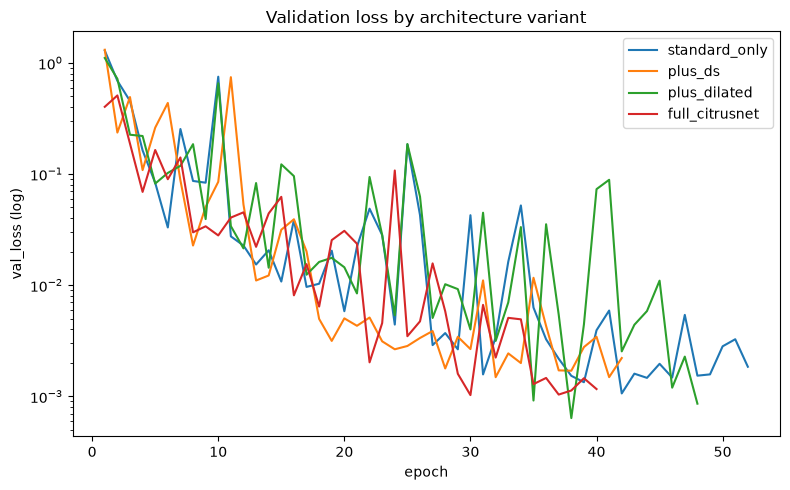

In [8]:
plt.figure(figsize=(8, 5))
for name, df in all_histories.items():
    plt.plot(df["epoch"], df["val_loss"], label=name)

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("val_loss (log)")
plt.title("Validation loss by architecture variant")
plt.legend()
plt.tight_layout()
plt.show()

### Val accuracy, early-training view

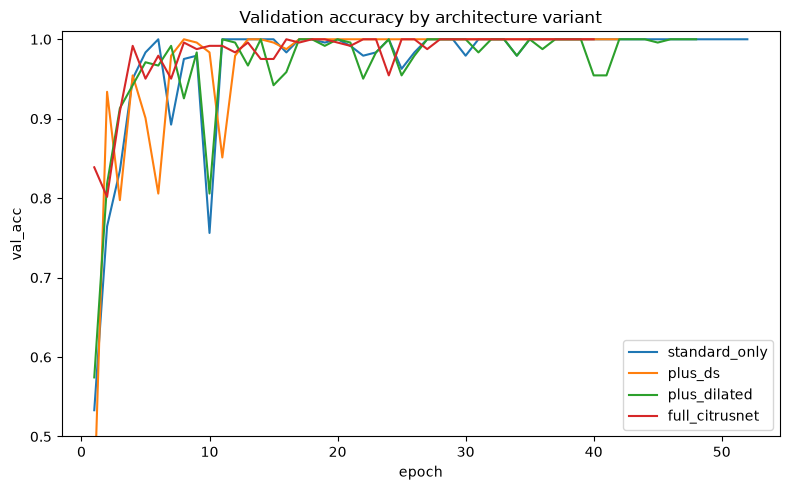

In [9]:
plt.figure(figsize=(8, 5))
for name, df in all_histories.items():
    plt.plot(df["epoch"], df["val_acc"], label=name)

plt.ylim(0.5, 1.01)
plt.xlabel("epoch")
plt.ylabel("val_acc")
plt.title("Validation accuracy by architecture variant")
plt.legend()
plt.tight_layout()
plt.show()

### Summary

In [10]:
sort_key = summary_df["epochs_to_reach_99pct"].apply(lambda v: float("inf") if v == "never" else v)
fastest_row = summary_df.loc[sort_key.idxmin()]
lowest_loss_row = summary_df.loc[summary_df["best_val_loss"].idxmin()]

print(f"fastest to 99% val acc: {fastest_row['variant']} (epoch {fastest_row['epochs_to_reach_99pct']})")
print(f"lowest best val loss: {lowest_loss_row['variant']} ({lowest_loss_row['best_val_loss']:.6f})")
print(f"plus_dilated matches standard_only param count: {dilated_matches_standard}")
print(f"plus_ds has fewer params than standard_only: {ds_is_fewer}")

fastest to 99% val acc: full_citrusnet (epoch 4)
lowest best val loss: plus_dilated (0.000638)
plus_dilated matches standard_only param count: True
plus_ds has fewer params than standard_only: True
